# Fase 3: Modelado Predictivo Base (Diagnóstico y Severidad)

**Objetivo de este Notebook:**
En esta fase, vamos a establecer nuestra línea base de rendimiento. Utilizaremos todas las características extraídas en los dominios del Tiempo y la Frecuencia para entrenar modelos de Machine Learning (Random Forest) capaces de entender la salud del motor.

El problema industrial se abordará en dos etapas:
1. **Diagnóstico (Clasificación):** ¿Qué tipo de fallo tiene el motor?
2. **Pronóstico de Severidad (Regresión):** Una vez detectado el problema, ¿cuál es su magnitud física exacta (mm o gramos)?

---

## 1. Contexto Físico: La Frecuencia de Muestreo
Antes de modelar, es vital entender la resolución temporal de nuestros datos. La telemetría se ha capturado con una **frecuencia de muestreo de 51.2 kHz** (51.200 muestras por segundo).

El periodo de muestreo $t$ se calcula como:
$$t = \frac{1}{f_s} = \frac{1}{51200} = 19.53 \, \mu s$$

*Valor para el negocio:* Esto significa que el sistema monitoriza el motor cada **19.53 microsegundos**. Esta altísima resolución es lo que nos permite captar los milisegundos exactos en los que una bola del rodamiento golpea una fisura.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis, skew
import glob
import os 
from scipy.fftpack import fft, fftfreq
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

## 2. Etapa de Diagnóstico: Clasificación General de Anomalías
En esta etapa, entrenamos modelos de clasificación (`RandomForestClassifier`) para identificar la naturaleza de la avería. Evaluaremos la capacidad predictiva de la IA escalando la complejidad de los datos en tres fases: primero con el Dominio del Tiempo, luego con el Dominio de la Frecuencia, y finalmente fusionando ambos.

### 2.1. Diagnóstico mediante el Dominio del Tiempo
Comenzamos entrenando un modelo utilizando exclusivamente los estadísticos temporales (energía e impactos). Esta métrica es excelente para captar anomalías estructurales globales.

In [12]:
time_features = pd.read_csv('../../Datos/Transformados/features_dom_tiempo.csv')

In [13]:
time_features['clase'].value_counts()

clase
imbalance                  333
vertical-misalignment      301
horizontal-misalignment    197
overhang_outer_race        188
underhang_cage_fault       188
overhang_cage_fault        188
underhang_ball_fault       186
underhang_outer_race       184
overhang_ball_fault        137
normal                      49
Name: count, dtype: int64

In [14]:
X = time_features.drop(columns=['clase', 'subclase', 'file_path'])
y = time_features['clase']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
os.makedirs('../../Datos/Transformados/modelos/all_variables', exist_ok=True)

joblib.dump(clf, '../../Datos/Transformados/modelos/all_variables/time_features_class_prediction.pkl')

# Hacer predicciones
y_pred = clf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
                         precision    recall  f1-score   support

horizontal-misalignment       0.98      0.96      0.97        50
              imbalance       0.99      0.98      0.99       109
                 normal       1.00      0.94      0.97        18
    overhang_ball_fault       1.00      1.00      1.00        44
    overhang_cage_fault       0.94      0.98      0.96        50
    overhang_outer_race       0.98      0.95      0.97        63
   underhang_ball_fault       1.00      1.00      1.00        44
   underhang_cage_fault       0.98      1.00      0.99        60
   underhang_outer_race       1.00      1.00      1.00        57
  vertical-misalignment       0.98      1.00      0.99        91

               accuracy                           0.98       586
              macro avg       0.99      0.98      0.98       586
           weighted avg       0.98      0.98      0.98       586



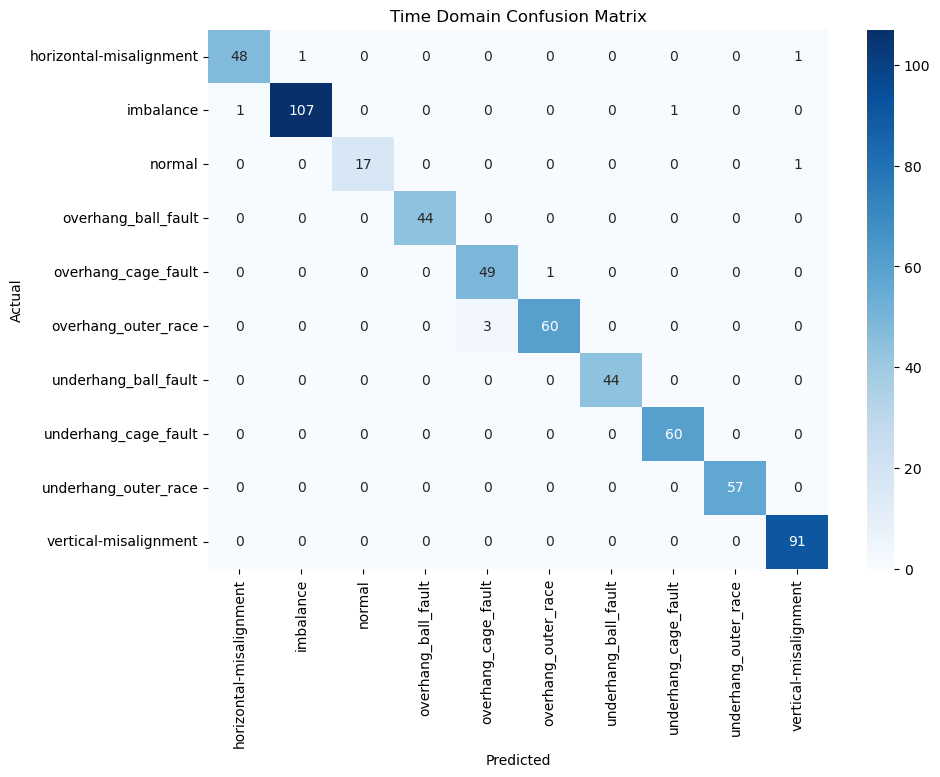

In [16]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Time Domain Confusion Matrix')
plt.show()

### 2.2. Diagnóstico mediante el Dominio de la Frecuencia (FFT)

In [17]:
frequency_features = pd.read_csv('../../Datos/Transformados/features_dom_frecuencia.csv')

In [18]:
frequency_features.clase.value_counts()

clase
imbalance                  333
vertical-misalignment      301
horizontal-misalignment    197
overhang_outer_race        188
underhang_cage_fault       188
overhang_cage_fault        188
underhang_ball_fault       186
underhang_outer_race       184
overhang_ball_fault        137
normal                      49
Name: count, dtype: int64

Classification Report:
                         precision    recall  f1-score   support

horizontal-misalignment       1.00      0.94      0.97        50
              imbalance       0.99      0.98      0.99       109
                 normal       1.00      0.78      0.88        18
    overhang_ball_fault       1.00      1.00      1.00        44
    overhang_cage_fault       0.89      1.00      0.94        50
    overhang_outer_race       1.00      0.94      0.97        63
   underhang_ball_fault       1.00      1.00      1.00        44
   underhang_cage_fault       0.98      1.00      0.99        60
   underhang_outer_race       1.00      1.00      1.00        57
  vertical-misalignment       0.93      0.98      0.95        91

               accuracy                           0.97       586
              macro avg       0.98      0.96      0.97       586
           weighted avg       0.98      0.97      0.97       586



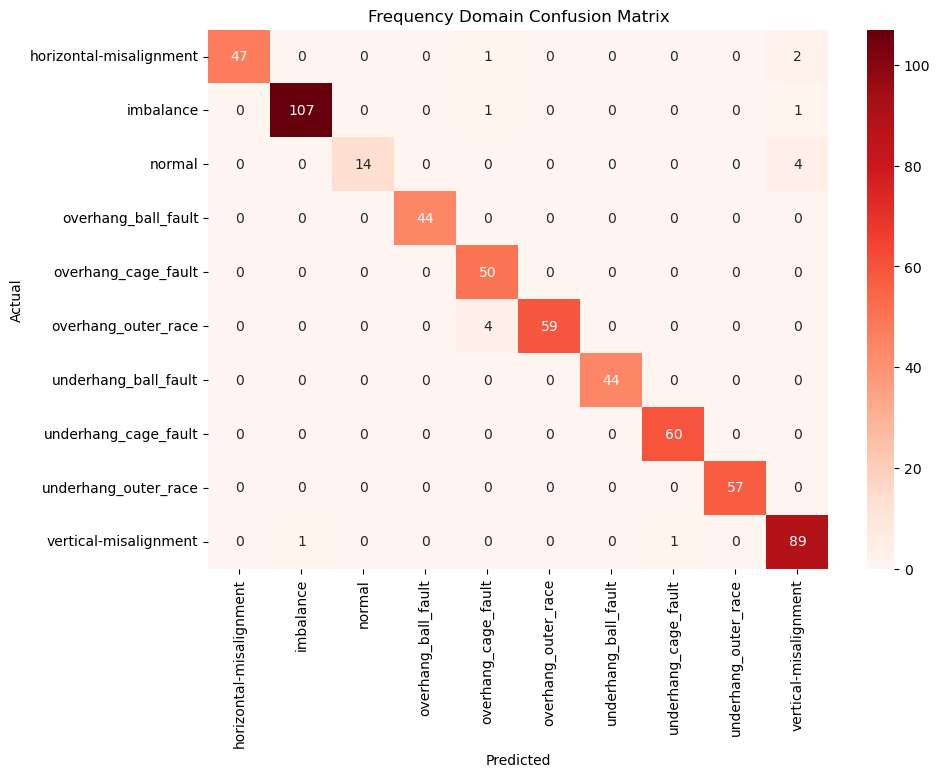

In [19]:
X_freq = frequency_features.drop(columns=['clase', 'subclase', 'file_path'])
y_freq = frequency_features['clase']
X_train, X_test, y_train, y_test = train_test_split(X_freq, y_freq, test_size=0.3, random_state=42)


clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

joblib.dump(clf, '../../Datos/Transformados/modelos/all_variables/frequency_features_class_prediction.pkl')


# Hacer predicciones
y_pred = clf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Frequency Domain Confusion Matrix')
plt.show()

### 2.3. Modelo Híbrido (Sensor Fusion: Tiempo + Frecuencia)

Entrenando Modelo Híbrido (Sensor Fusion)...
Classification Report (Híbrido):
                         precision    recall  f1-score   support

horizontal-misalignment       0.98      0.96      0.97        50
              imbalance       1.00      0.99      1.00       109
                 normal       1.00      0.94      0.97        18
    overhang_ball_fault       1.00      1.00      1.00        44
    overhang_cage_fault       0.93      1.00      0.96        50
    overhang_outer_race       1.00      0.95      0.98        63
   underhang_ball_fault       1.00      1.00      1.00        44
   underhang_cage_fault       1.00      1.00      1.00        60
   underhang_outer_race       1.00      1.00      1.00        57
  vertical-misalignment       0.98      1.00      0.99        91

               accuracy                           0.99       586
              macro avg       0.99      0.98      0.99       586
           weighted avg       0.99      0.99      0.99       586



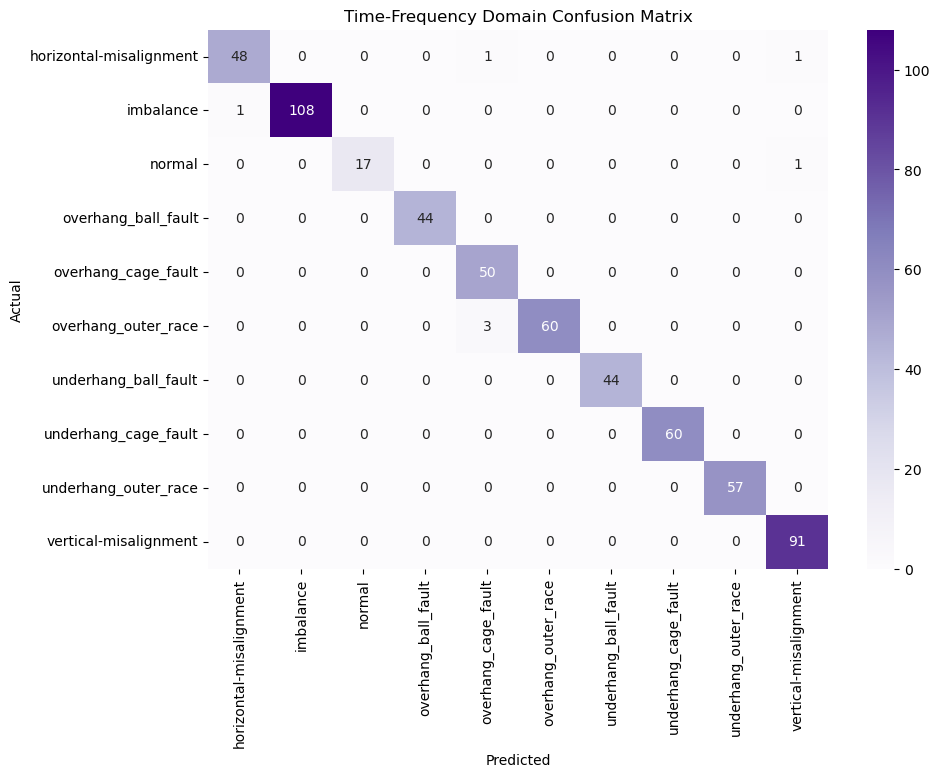

In [20]:
# --- MODELO HÍBRIDO: TIEMPO + FRECUENCIA ---
print("Entrenando Modelo Híbrido (Sensor Fusion)...")

# Unimos los datasets usando file_path para asegurarnos de que coinciden exactamente
freq_reduced = frequency_features.drop(columns=['clase', 'subclase'])
hibrido_df = pd.merge(time_features, freq_reduced, on='file_path')

X_hib = hibrido_df.drop(columns=['clase', 'subclase', 'file_path'])
y_hib = hibrido_df['clase']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_hib, y_hib, test_size=0.3, random_state=42)

clf_hib = RandomForestClassifier(n_estimators=100, random_state=42)
clf_hib.fit(X_train_h, y_train_h)

joblib.dump(clf_hib, '../../Datos/Transformados/modelos/all_variables/hybrid_features_class_prediction.pkl')

y_pred_h = clf_hib.predict(X_test_h)
print("Classification Report (Híbrido):")
print(classification_report(y_test_h, y_pred_h))

cm_h = confusion_matrix(y_test_h, y_pred_h)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_h, annot=True, fmt='d', cmap='Purples', xticklabels=clf_hib.classes_, yticklabels=clf_hib.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Time-Frequency Domain Confusion Matrix')
plt.show()

## 3. Etapa de Pronóstico: Modelos Especialistas de Severidad (Regresión)
Saber que un motor padece una "Desalineación" es útil para el diagnóstico, pero en un entorno real de Industria 4.0 necesitamos conocer la **gravedad física exacta** para programar el mantenimiento de forma óptima antes del colapso de la máquina.

Para lograrlo, diseñamos una arquitectura de **Modelos Especialistas**. En lugar de usar un único modelo general, el sistema filtra los datos por el tipo de fallo detectado en la etapa anterior y entrena un `RandomForestRegressor` dedicado exclusivamente a predecir variables continuas específicas (por ejemplo, los milímetros de una desalineación o los gramos de un desequilibrio).

### 3.1. Evaluación Multidominio Automatizada
A continuación, definimos una función modular que automatiza el entrenamiento, la evaluación de métricas (MSE, MAE, R2) y la visualización de estos modelos especialistas. Ejecutaremos esta validación secuencialmente para los tres conjuntos de datos: **Tiempo (Verde), Frecuencia (Rojo) e Híbrido (Púrpura)**.

=== INICIANDO REGRESIÓN: DOMINIO DEL TIEMPO ===


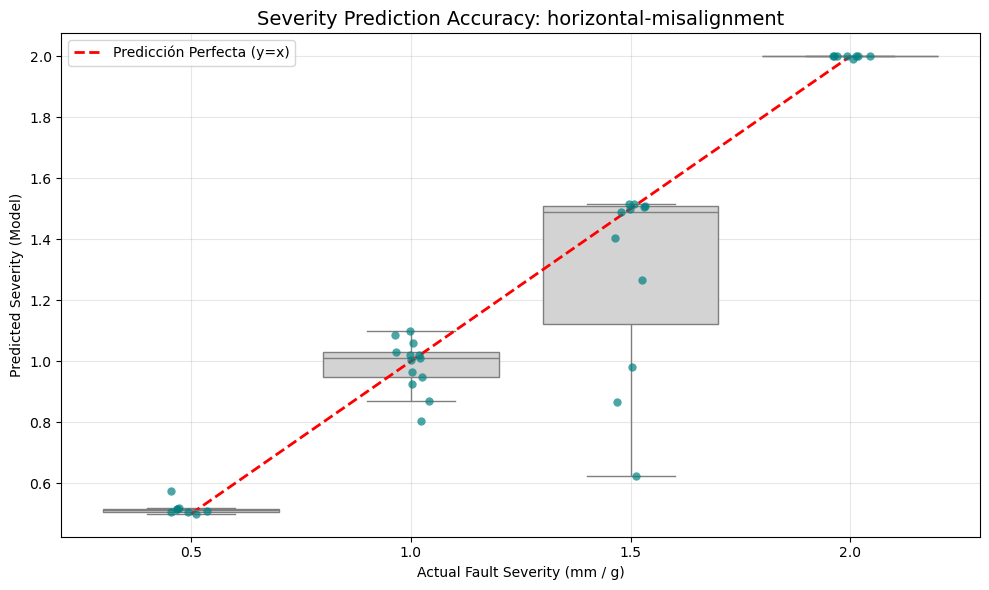

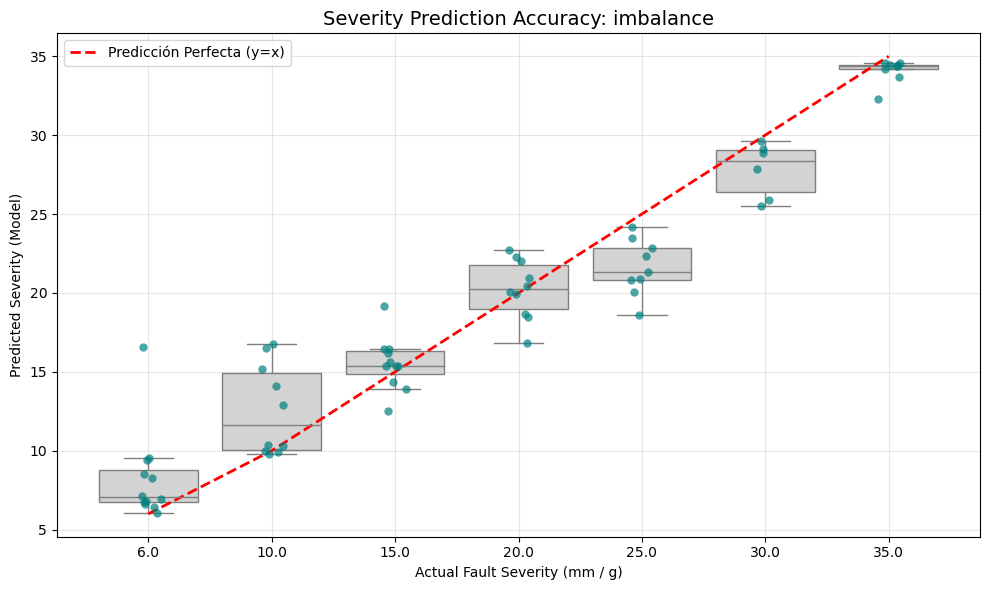

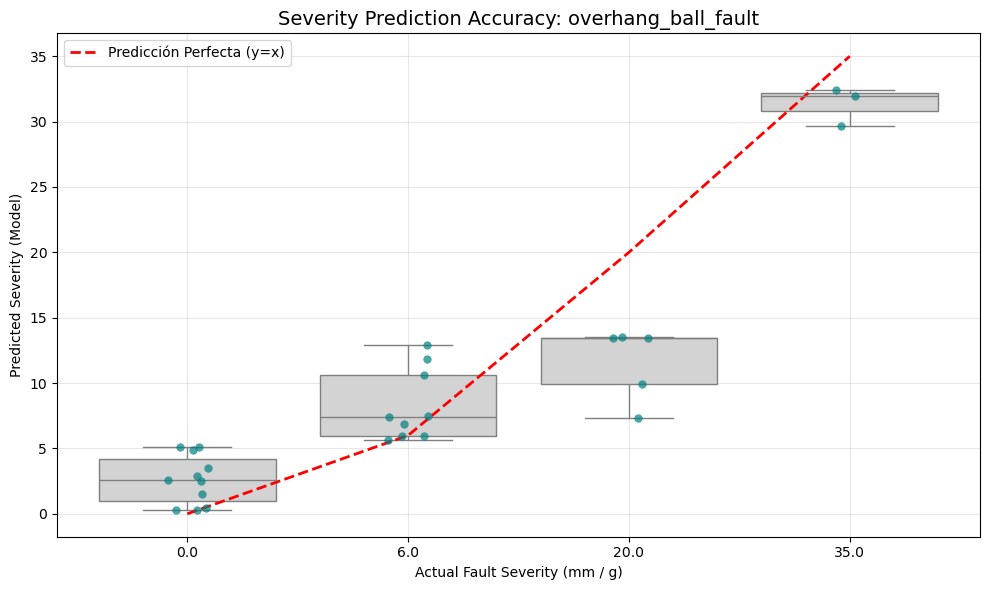

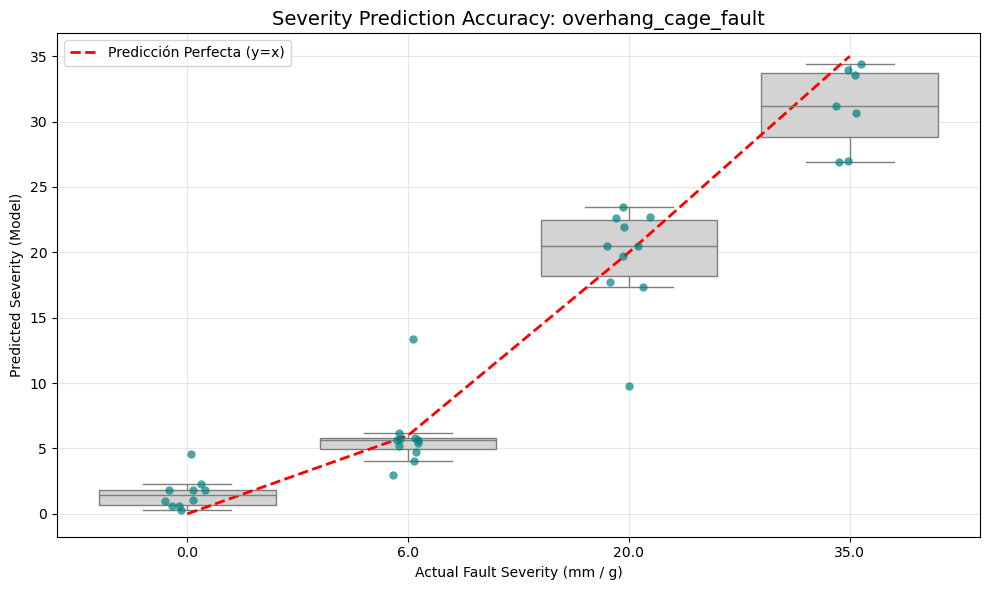

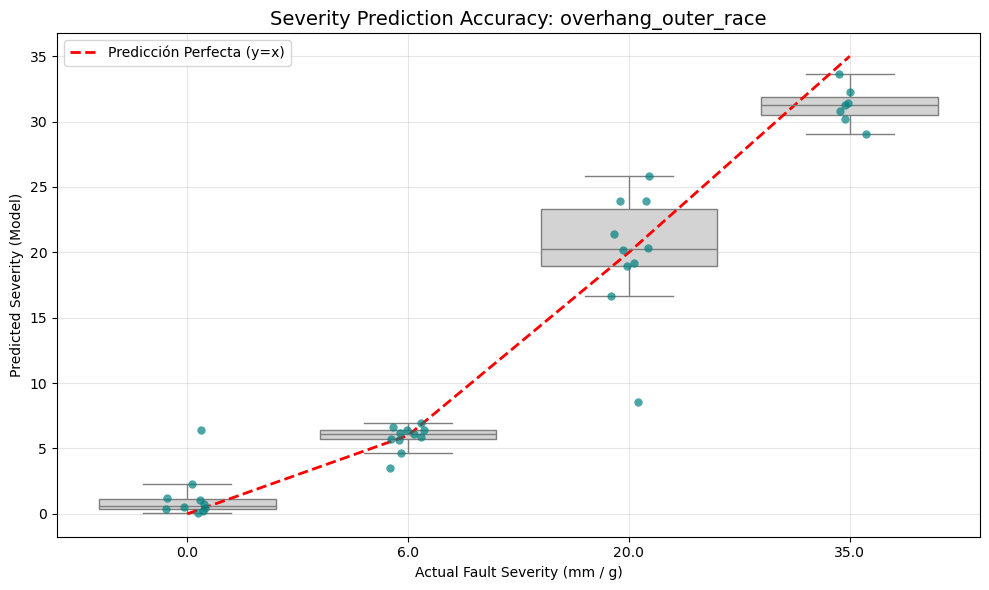

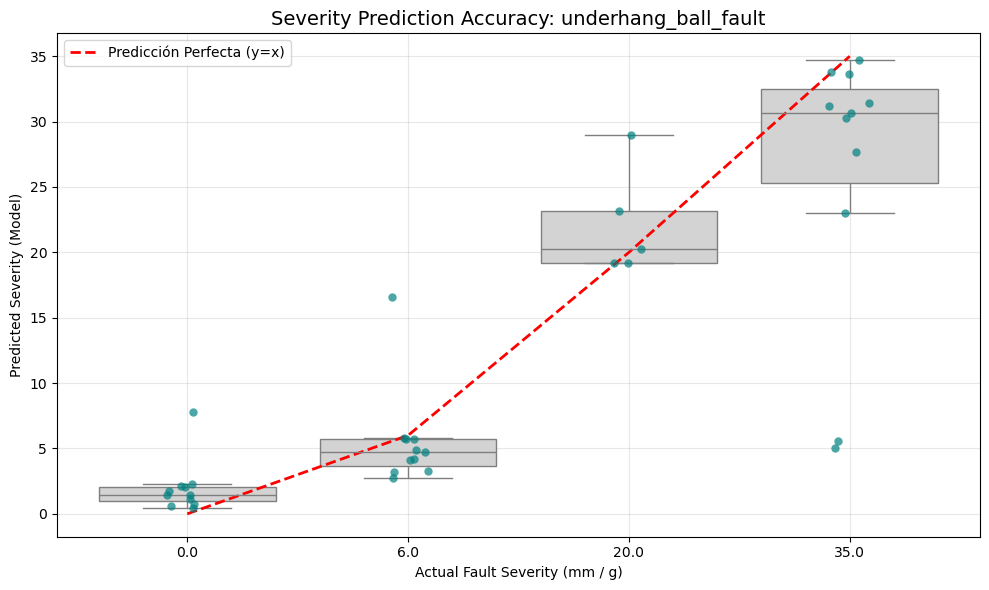

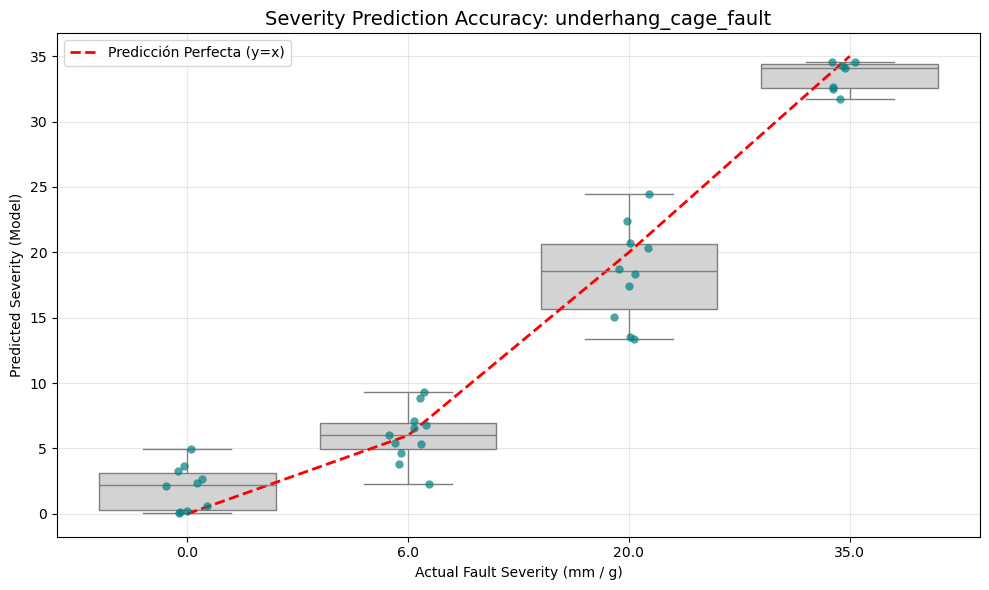

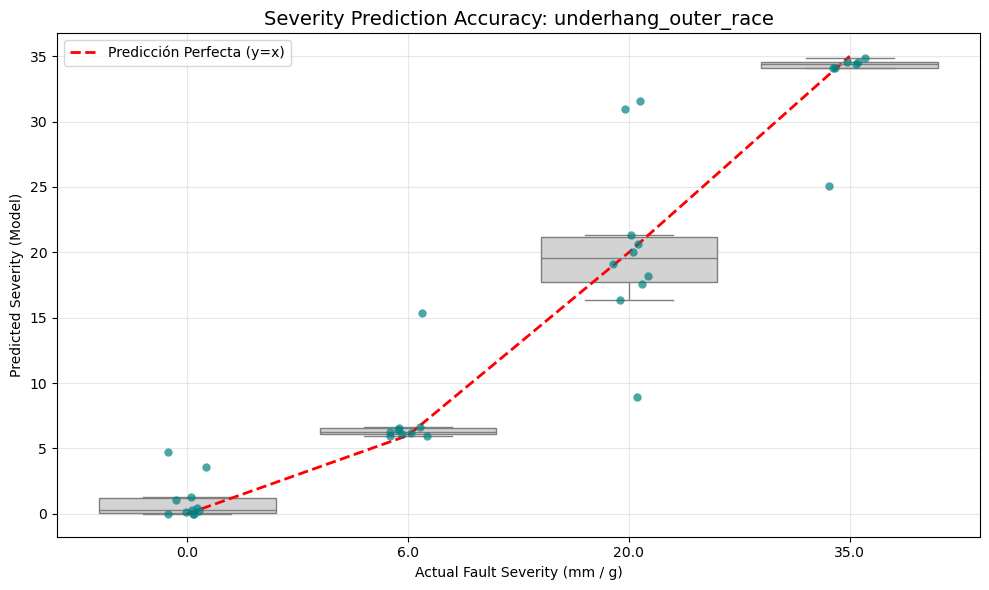

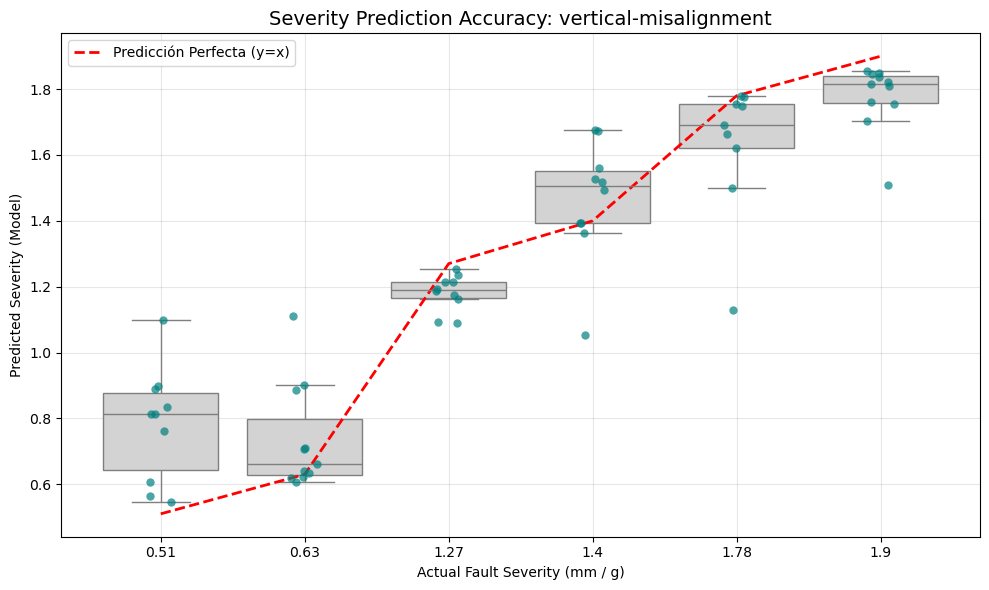


Proceso completado para el dominio: TIEMPO
  -> horizontal-misalignment | R2: 0.8477 | MAE: 0.0846
  -> imbalance | R2: 0.9154 | MAE: 2.0033
  -> overhang_ball_fault | R2: 0.8183 | MAE: 3.7118
  -> overhang_cage_fault | R2: 0.9308 | MAE: 2.2805
  -> overhang_outer_race | R2: 0.9372 | MAE: 2.0855
  -> underhang_ball_fault | R2: 0.7009 | MAE: 4.2124
  -> underhang_cage_fault | R2: 0.9540 | MAE: 2.0866
  -> underhang_outer_race | R2: 0.8979 | MAE: 2.1941
  -> vertical-misalignment | R2: 0.8453 | MAE: 0.1475

=== INICIANDO REGRESIÓN: DOMINIO DE LA FRECUENCIA ===


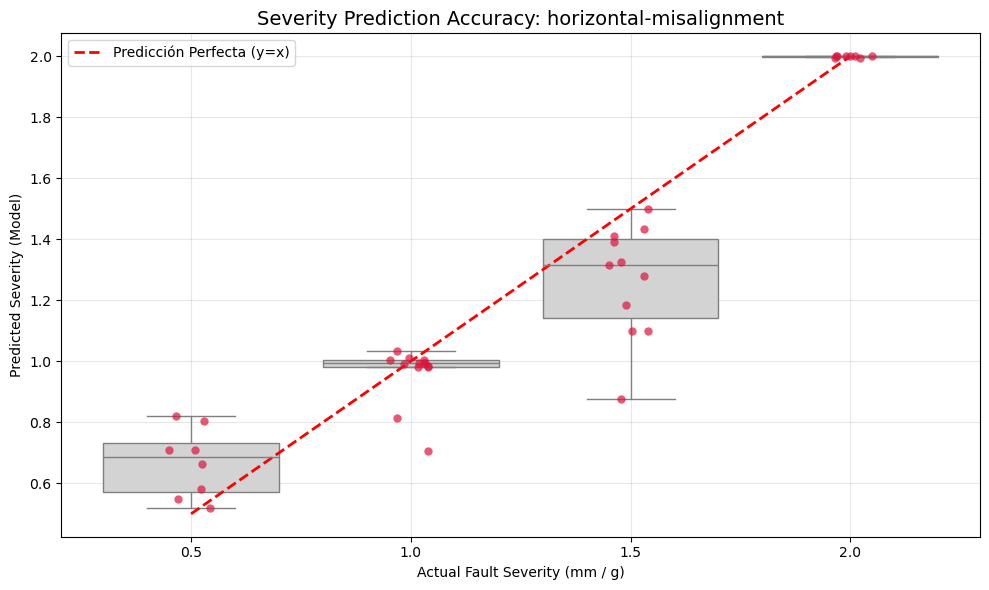

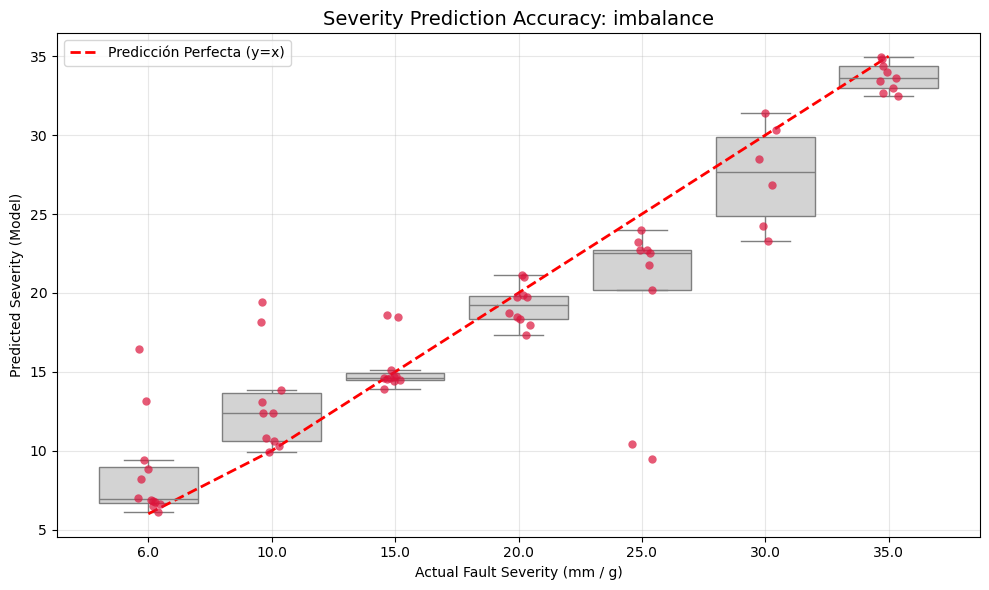

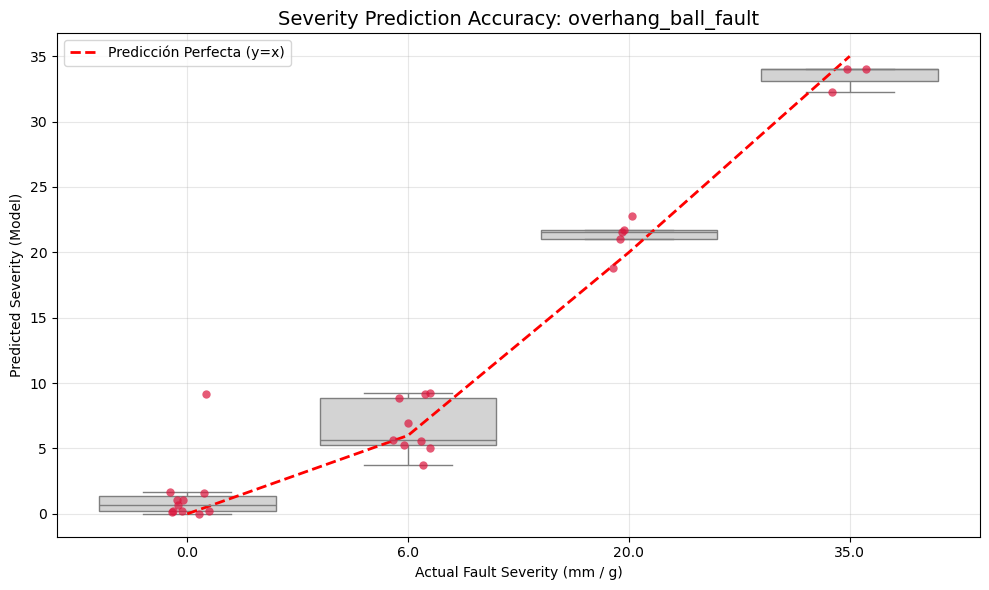

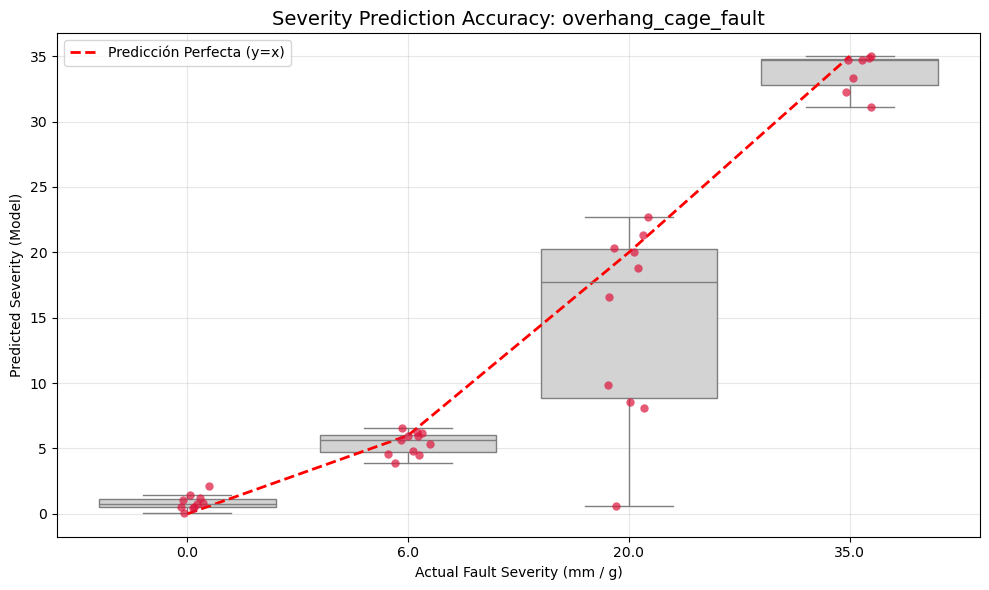

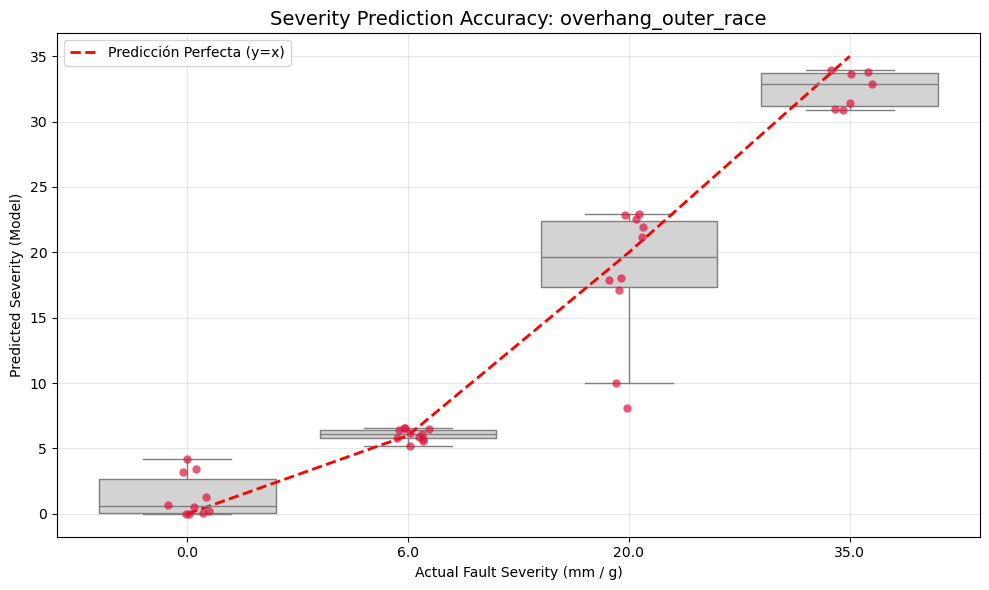

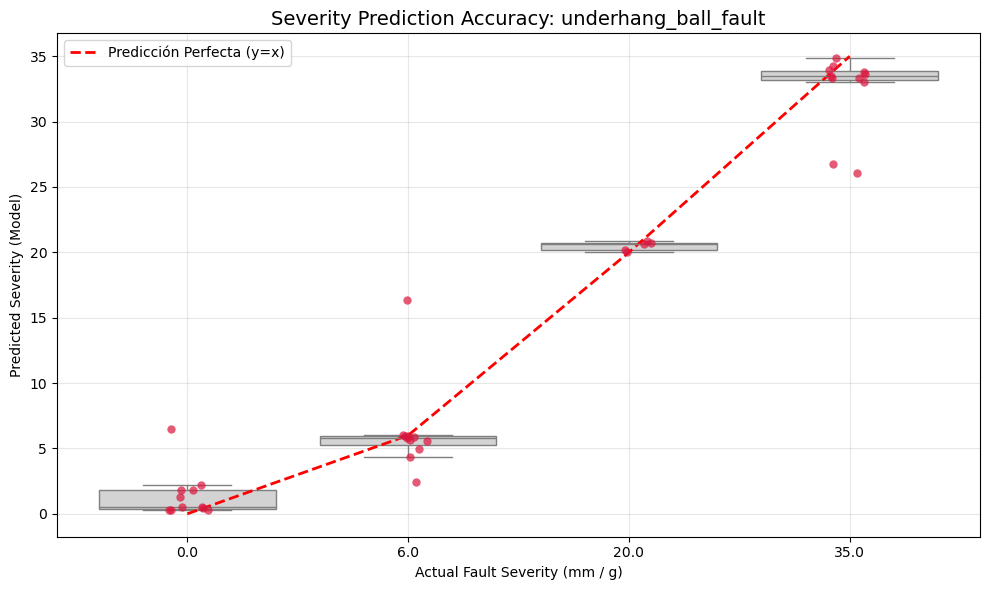

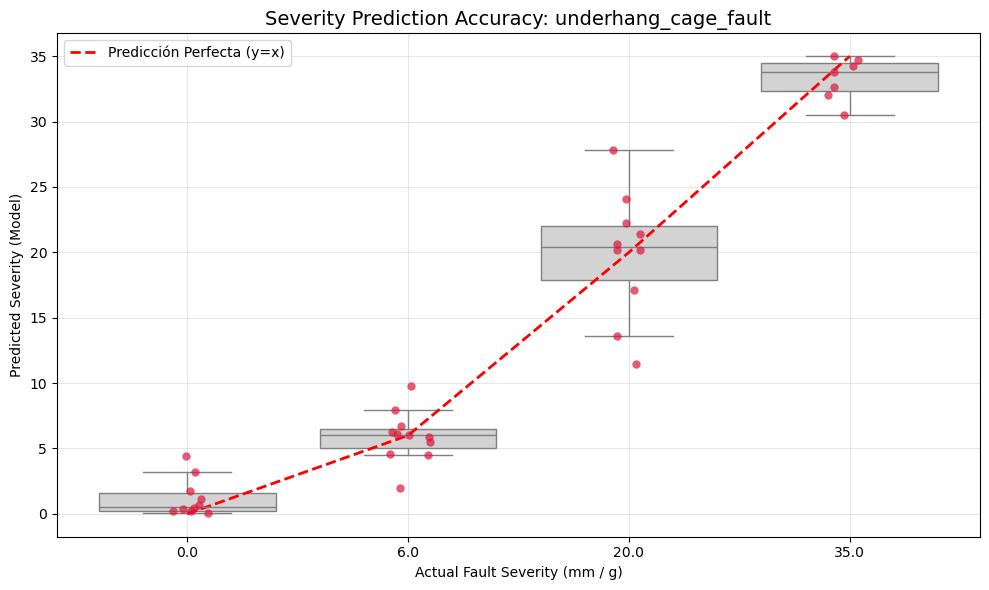

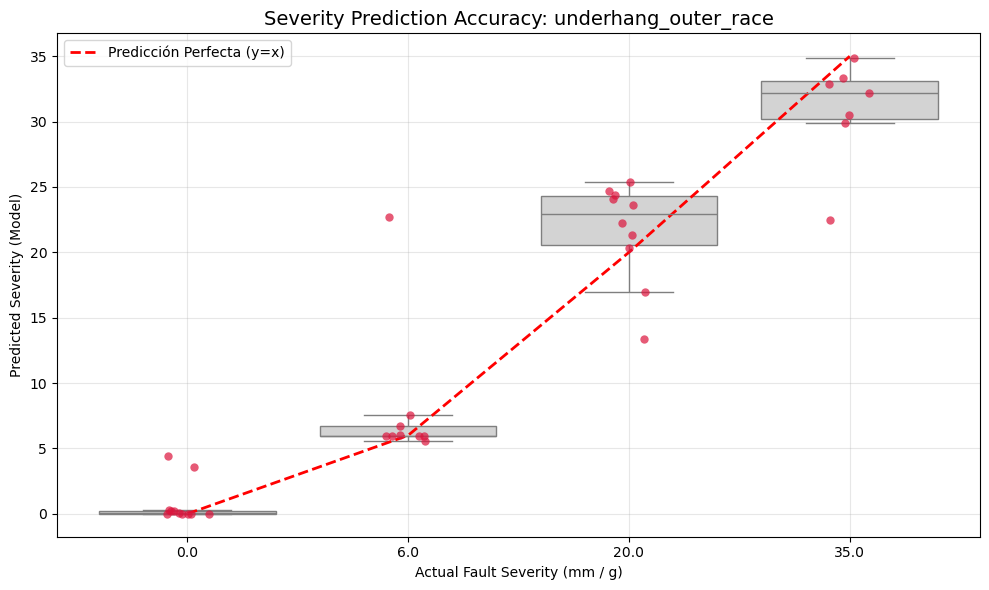

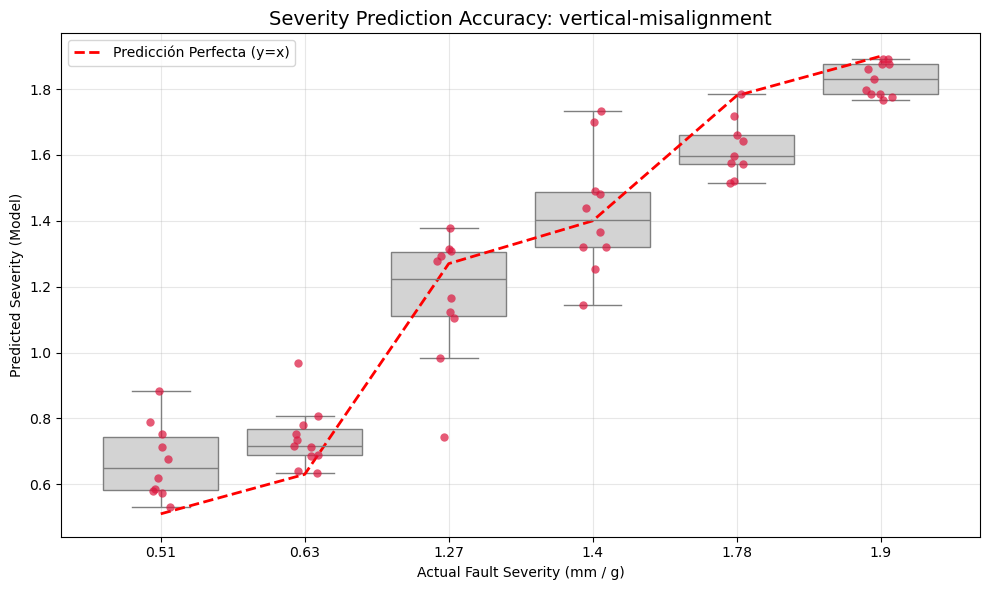


Proceso completado para el dominio: FRECUENCIA
  -> horizontal-misalignment | R2: 0.8674 | MAE: 0.1142
  -> imbalance | R2: 0.8356 | MAE: 2.4369
  -> overhang_ball_fault | R2: 0.9573 | MAE: 1.5668
  -> overhang_cage_fault | R2: 0.8653 | MAE: 2.3203
  -> overhang_outer_race | R2: 0.9368 | MAE: 1.9845
  -> underhang_ball_fault | R2: 0.9561 | MAE: 1.7026
  -> underhang_cage_fault | R2: 0.9477 | MAE: 1.9258
  -> underhang_outer_race | R2: 0.8875 | MAE: 2.5143
  -> vertical-misalignment | R2: 0.9002 | MAE: 0.1292

=== INICIANDO REGRESIÓN: MODELO HÍBRIDO ===


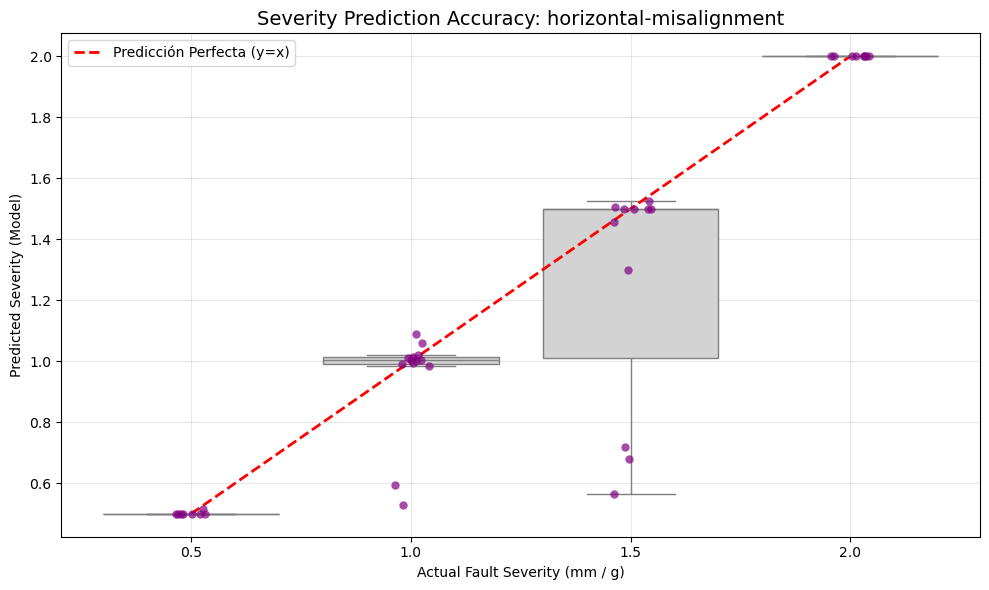

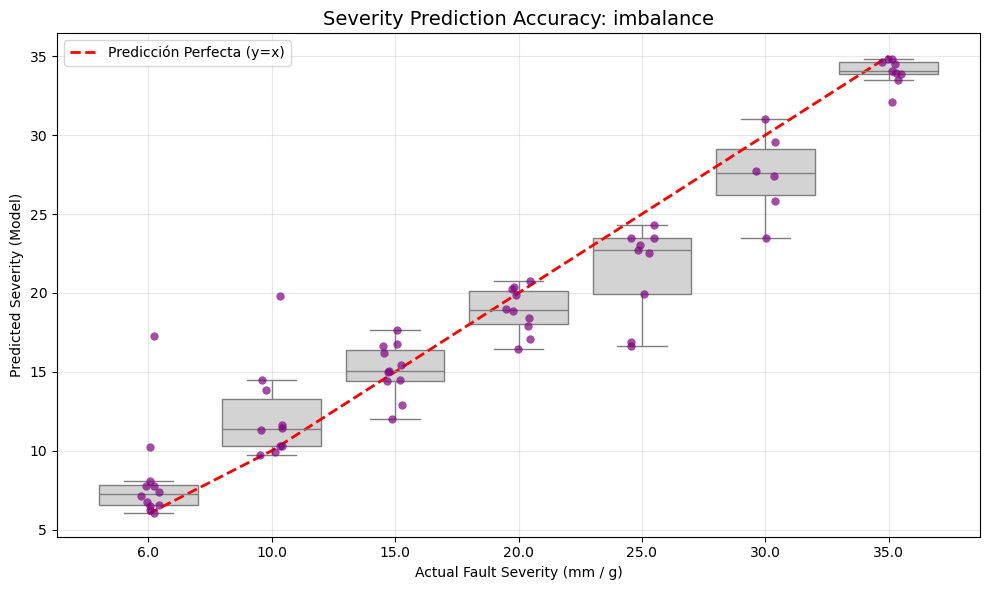

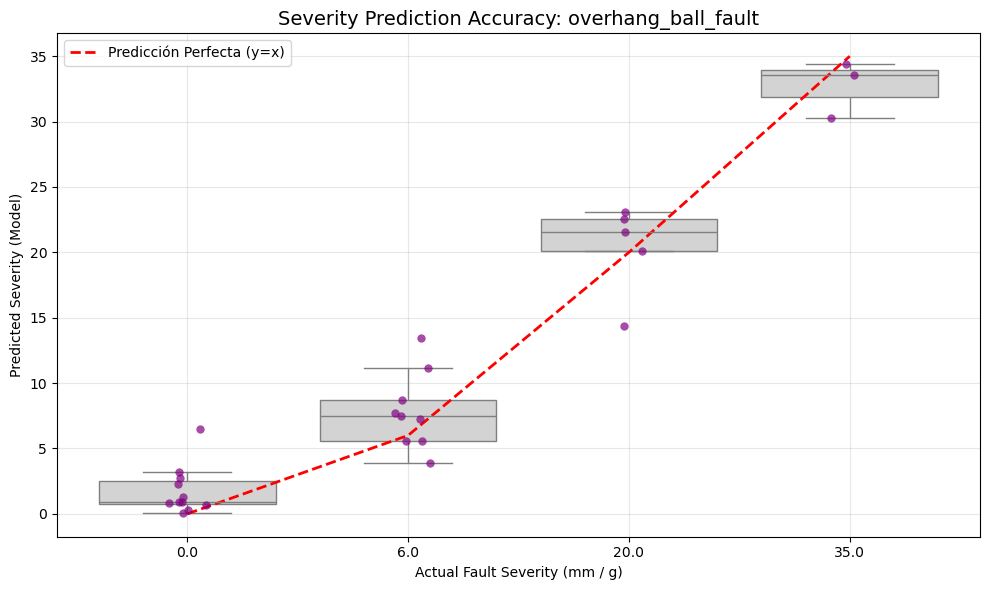

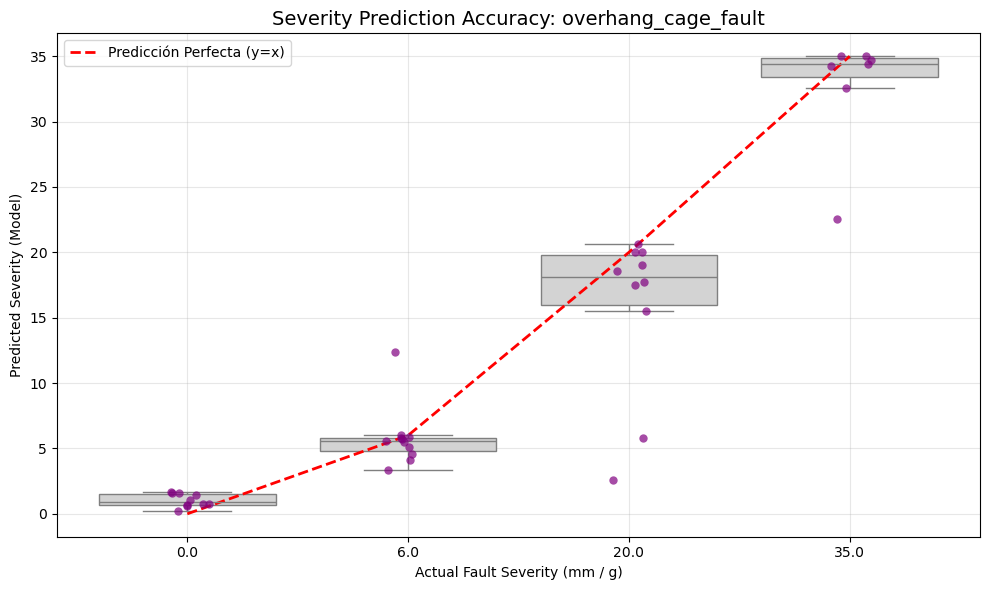

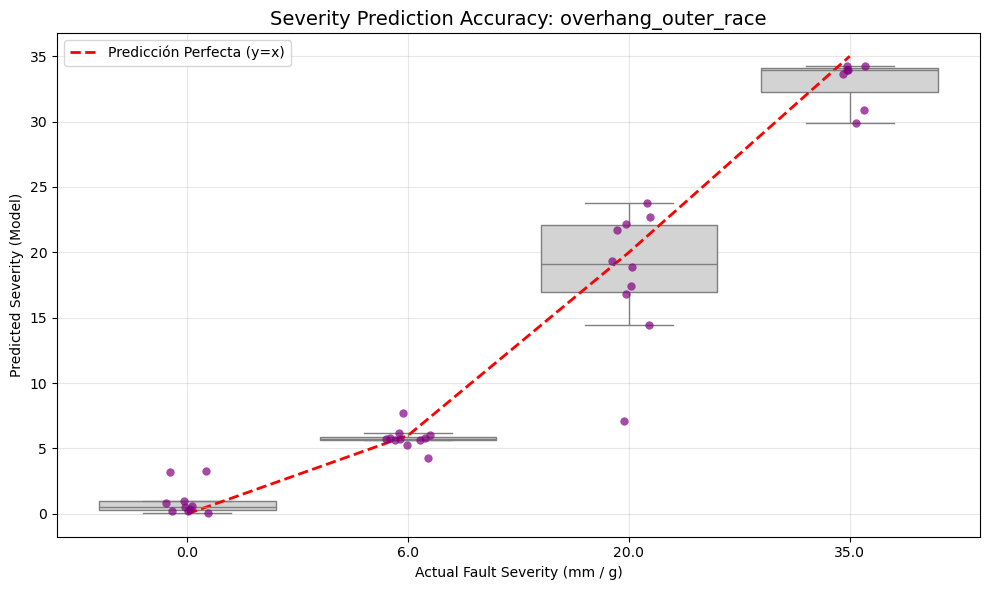

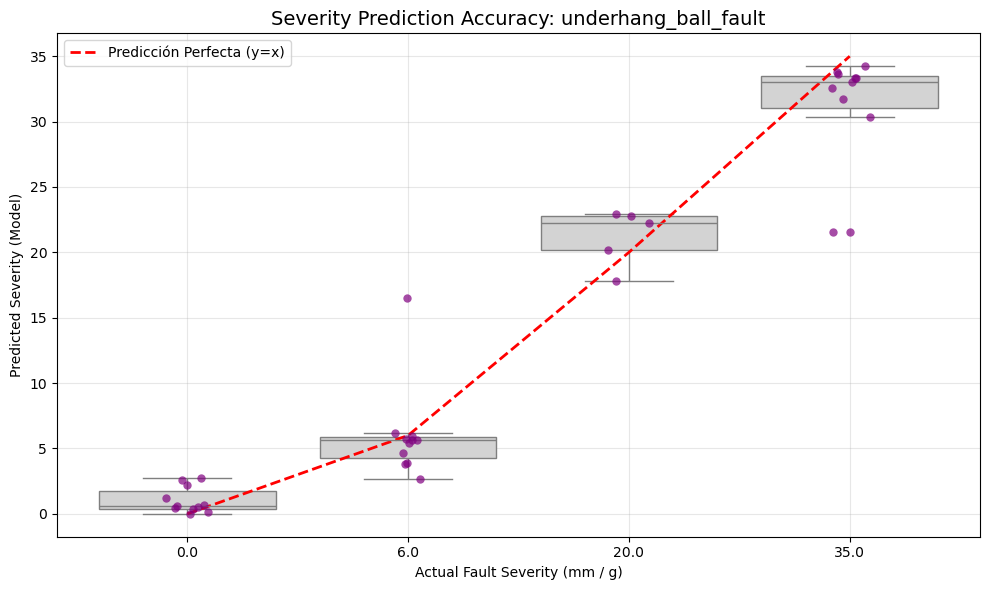

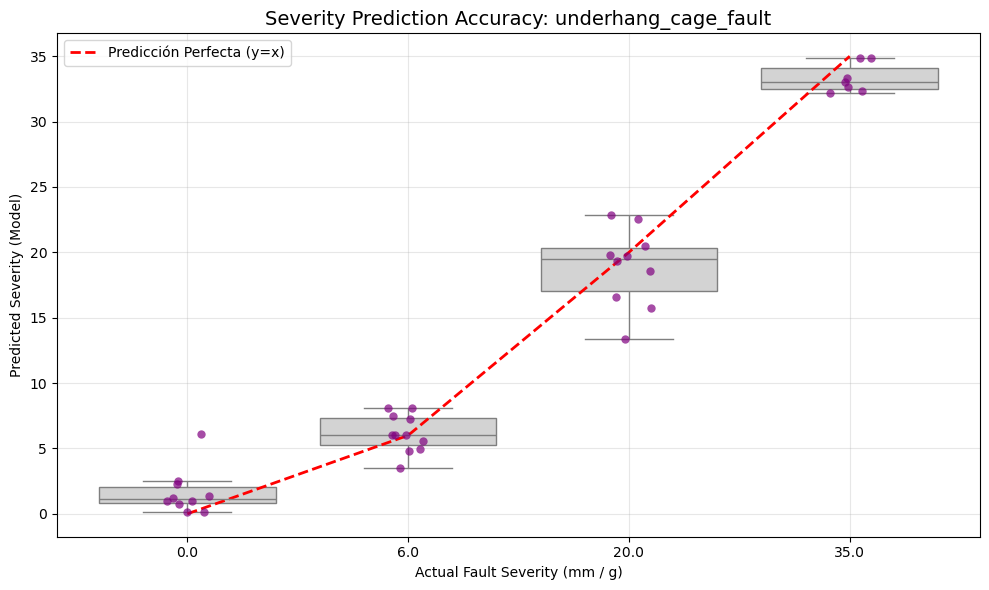

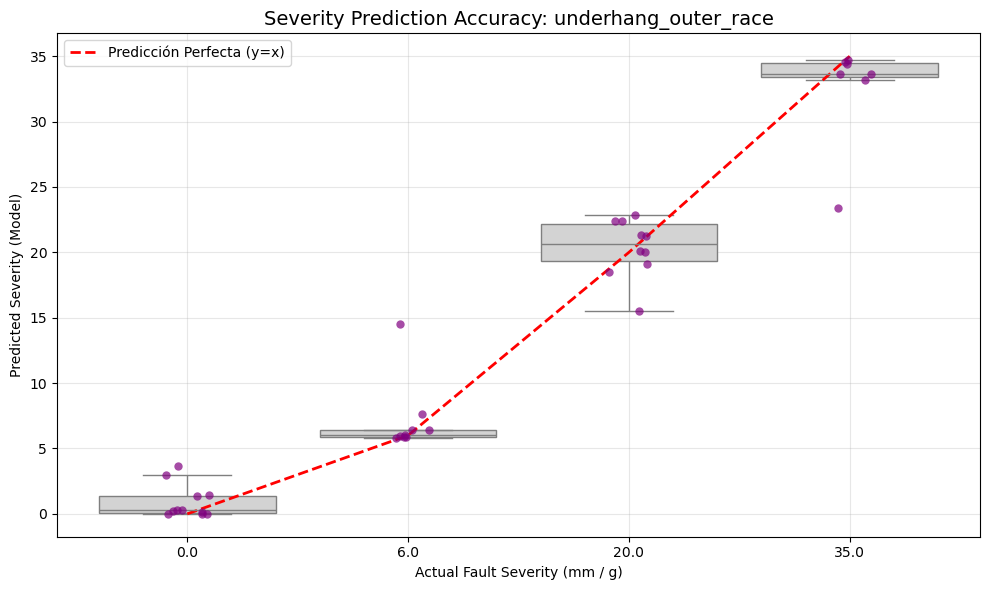

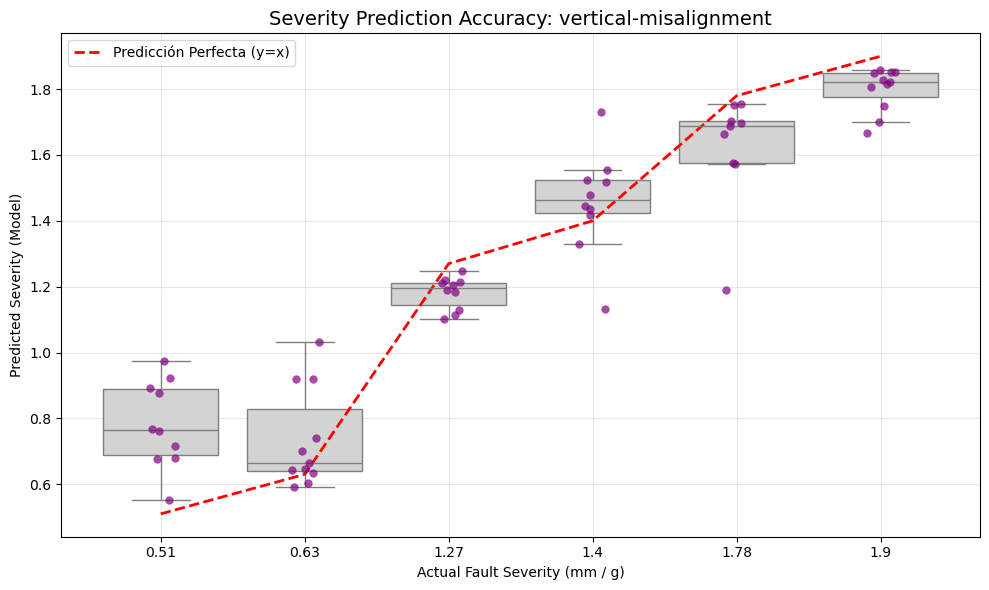


Proceso completado para el dominio: HIBRIDO
  -> horizontal-misalignment | R2: 0.7526 | MAE: 0.0984
  -> imbalance | R2: 0.9017 | MAE: 2.0118
  -> overhang_ball_fault | R2: 0.9321 | MAE: 2.2150
  -> overhang_cage_fault | R2: 0.8738 | MAE: 2.2518
  -> overhang_outer_race | R2: 0.9471 | MAE: 1.7576
  -> underhang_ball_fault | R2: 0.9247 | MAE: 2.3358
  -> underhang_cage_fault | R2: 0.9680 | MAE: 1.6650
  -> underhang_outer_race | R2: 0.9529 | MAE: 1.5249
  -> vertical-misalignment | R2: 0.8705 | MAE: 0.1420


In [21]:
# --- 3. ETAPA DE PRONÓSTICO: MODELOS ESPECIALISTAS DE SEVERIDAD (REGRESIÓN) ---
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Directorio general de guardado
output_dir = "../../Datos/Transformados/Modelos_subclase/all_variables"
os.makedirs(output_dir, exist_ok=True)

def entrenar_evaluar_regresores(df, nombre_dominio, color_grafica):
    """
    Filtra el dataset por clase de fallo, entrena un regresor para predecir 
    la severidad y genera visualizaciones y métricas.
    """
    df_copy = df.copy()
    # Limpiamos las letras para dejar solo el valor numérico (float)
    df_copy['subclase'] = df_copy['subclase'].astype(str).str.replace('g', '').str.replace('mm', '').astype(float)
    
    metricas_subclase = {}
    
    for clase in df_copy['clase'].unique():
        if clase == 'normal': continue
            
        df_clase = df_copy[df_copy['clase'] == clase]
        X = df_clase.drop(columns=['clase', 'subclase', 'file_path'])
        y = df_clase['subclase']
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Entrenamiento
        modelo = RandomForestRegressor(n_estimators=100, random_state=42)
        modelo.fit(X_train, y_train)
        
        # Guardado del modelo
        model_path = os.path.join(output_dir, f"{nombre_dominio}_{clase}_regressor.pkl")
        joblib.dump(modelo, model_path)
        
        # Predicción y Métricas
        y_pred = modelo.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        metricas_subclase[clase] = {
            'MSE': mse, 'RMSE': mse ** 0.5, 
            'MAE': mean_absolute_error(y_test, y_pred), 'R2': r2_score(y_test, y_pred)
        }
        
        # --- VISUALIZACIÓN PROFESIONAL ---
        plt.figure(figsize=(10, 6))
        y_test_rounded = np.round(y_test, 2)
        
        sns.boxplot(x=y_test_rounded, y=y_pred, color='lightgray', showfliers=False)
        sns.stripplot(x=y_test_rounded, y=y_pred, color=color_grafica, alpha=0.7, jitter=True, size=6)
        
        valores_unicos = np.sort(np.unique(y_test_rounded))
        x_ticks = np.arange(len(valores_unicos))
        plt.plot(x_ticks, valores_unicos, '--r', linewidth=2, label='Predicción Perfecta (y=x)')
        
        plt.xlabel('Actual Fault Severity (mm / g)')
        plt.ylabel('Predicted Severity (Model)')
        plt.title(f'Severity Prediction Accuracy: {clase}', fontsize=14)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # Guardado de métricas globales
    metrics_path = os.path.join(output_dir, f"metricas_subclase_{nombre_dominio}.json")
    with open(metrics_path, 'w') as f:
        json.dump(metricas_subclase, f, indent=4)
        
    print(f"\nProceso completado para el dominio: {nombre_dominio.upper()}")
    for clase, metricas in metricas_subclase.items():
        print(f"  -> {clase} | R2: {metricas['R2']:.4f} | MAE: {metricas['MAE']:.4f}")

# ==========================================
# EJECUCIÓN DE LOS 3 DOMINIOS CON UNA LÍNEA
# ==========================================
print("=== INICIANDO REGRESIÓN: DOMINIO DEL TIEMPO ===")
entrenar_evaluar_regresores(time_features, "tiempo", "teal")

print("\n=== INICIANDO REGRESIÓN: DOMINIO DE LA FRECUENCIA ===")
entrenar_evaluar_regresores(frequency_features, "frecuencia", "crimson")

print("\n=== INICIANDO REGRESIÓN: MODELO HÍBRIDO ===")
entrenar_evaluar_regresores(hibrido_df, "hibrido", "purple")

---

## 4. Conclusión del Modelado Base
El rendimiento de los modelos en esta fase preliminar es excepcionalmente alto. Hemos demostrado que la Inteligencia Artificial no solo es capaz de diagnosticar la pieza averiada con precisiones casi perfectas, sino que además logra predecir la severidad en milímetros con errores mínimos (bajos valores de MAE y alto R2), validando la teoría física vista en la Fase 1: un motor averiado no vibra más fuerte, vibra diferente.

**Siguiente paso (Optimización y Despliegue):** Aunque el modelo es preciso, actualmente depende de la ingesta de más de 200 variables matemáticas (150 espectrales + 69 temporales). En un entorno de computación *Edge* industrial (dispositivos IoT instalados a pie de máquina), calcular todo esto en tiempo real consume demasiada memoria y energía. 

En la **Fase 4**, aplicaremos técnicas avanzadas de **Selección de Características (Feature Selection)** para eliminar variables redundantes y encontrar el número mínimo de sensores e indicadores necesarios para mantener este 100% de precisión.